In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../datasets/final_dataset_missing_value_imputed_v5.csv')

In [4]:
df.shape

(3542, 19)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score
0,house,independent,sector 25,4.35,32222.0,5,4,3,3.0,Old Property,R70162684,1350.0,0,0,0,1,0,0,49
1,flat,the close south,sector 50,3.10,12444.0,3,4,3+,4.0,Moderately Old,H69433380,2450.0,0,0,0,1,0,2,165
2,flat,signature global city 63a,sector 63a,1.65,15263.0,2,2,2,1.0,Under Construction,G69165782,978.0,0,0,0,0,0,0,0
3,flat,saan verdante,sector 95,2.00,10178.0,3,4,3+,5.0,New Property,U70096330,1964.0,0,0,0,1,0,0,49
4,flat,puri diplomatic greens,sector 111,3.90,13000.0,4,5,3+,6.0,Relatively New,S69742910,2996.0,0,0,0,1,0,1,160


In [6]:
train_df = df.drop(columns=['society', 'price_per_sqft'])

In [7]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score
0,house,sector 25,4.35,5,4,3,3.0,Old Property,R70162684,1350.0,0,0,0,1,0,0,49
1,flat,sector 50,3.10,3,4,3+,4.0,Moderately Old,H69433380,2450.0,0,0,0,1,0,2,165
2,flat,sector 63a,1.65,2,2,2,1.0,Under Construction,G69165782,978.0,0,0,0,0,0,0,0
3,flat,sector 95,2.00,3,4,3+,5.0,New Property,U70096330,1964.0,0,0,0,1,0,0,49
4,flat,sector 111,3.90,4,5,3+,6.0,Relatively New,S69742910,2996.0,0,0,0,1,0,1,160


<Axes: >

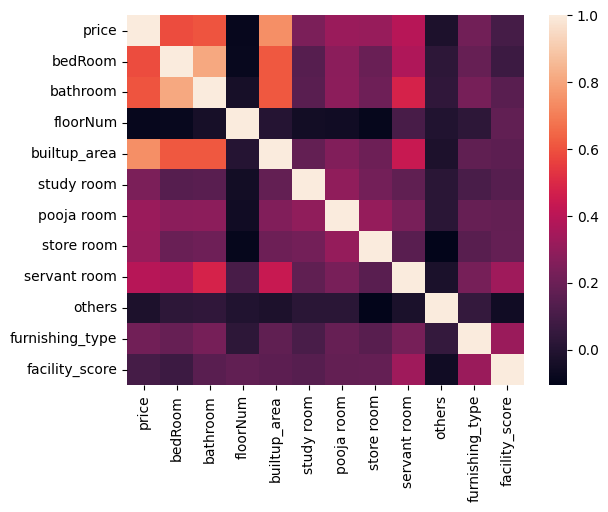

In [8]:
sns.heatmap(train_df.corr(numeric_only=True))

In [9]:
# dependence of variable on price
train_df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price              1.000000
builtup_area       0.745015
bathroom           0.606704
bedRoom            0.589577
servant room       0.392914
pooja room         0.319299
store room         0.309234
study room         0.242112
furnishing_type    0.215467
facility_score     0.097497
others            -0.021007
floorNum          -0.087836
Name: price, dtype: float64

<Axes: xlabel='facility_score'>

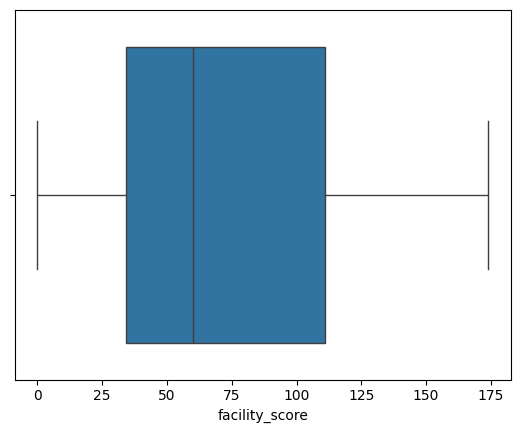

In [11]:
sns.boxplot(x='facility_score', data=train_df)

numerical data isn't helping much will convert into categorical data: budget friendly, semi luxirious, luxirious likewise.

In [12]:
def categorize_facility_score(score):
    if(0 <= score < 50):
        return "Low"
    elif(50 <= score < 150):
        return "Medium"
    elif 150 <= score < 175:
        return "High"
    else:
        return None

In [13]:
train_df['facility_category'] = train_df['facility_score'].apply(categorize_facility_score)

In [14]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score,facility_category
0,house,sector 25,4.35,5,4,3,3.0,Old Property,R70162684,1350.0,0,0,0,1,0,0,49,Low
1,flat,sector 50,3.10,3,4,3+,4.0,Moderately Old,H69433380,2450.0,0,0,0,1,0,2,165,High
2,flat,sector 63a,1.65,2,2,2,1.0,Under Construction,G69165782,978.0,0,0,0,0,0,0,0,Low
3,flat,sector 95,2.00,3,4,3+,5.0,New Property,U70096330,1964.0,0,0,0,1,0,0,49,Low
4,flat,sector 111,3.90,4,5,3+,6.0,Relatively New,S69742910,2996.0,0,0,0,1,0,1,160,High


#### floorNum

in real we won't take exact floor num for an input instead it will be taken as range so we'll convert it to categorical col on basis of floor range.

<Axes: xlabel='floorNum'>

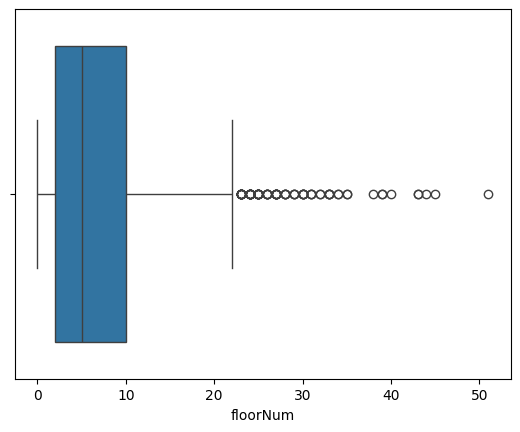

In [16]:
sns.boxplot(x='floorNum', data=train_df)

In [15]:
def floor_range(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [17]:
train_df['floor_category'] = train_df['floorNum'].apply(floor_range)

In [18]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score,facility_category,floor_category
0,house,sector 25,4.35,5,4,3,3.0,Old Property,R70162684,1350.0,0,0,0,1,0,0,49,Low,Mid Floor
1,flat,sector 50,3.10,3,4,3+,4.0,Moderately Old,H69433380,2450.0,0,0,0,1,0,2,165,High,Mid Floor
2,flat,sector 63a,1.65,2,2,2,1.0,Under Construction,G69165782,978.0,0,0,0,0,0,0,0,Low,Low Floor
3,flat,sector 95,2.00,3,4,3+,5.0,New Property,U70096330,1964.0,0,0,0,1,0,0,49,Low,Mid Floor
4,flat,sector 111,3.90,4,5,3+,6.0,Relatively New,S69742910,2996.0,0,0,0,1,0,1,160,High,Mid Floor


In [20]:
# removing irrelevant cols
train_df.drop(columns=['facility_score', 'floorNum'], inplace=True)

In [21]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_category,floor_category
0,house,sector 25,4.35,5,4,3,Old Property,R70162684,1350.0,0,0,0,1,0,0,Low,Mid Floor
1,flat,sector 50,3.10,3,4,3+,Moderately Old,H69433380,2450.0,0,0,0,1,0,2,High,Mid Floor
2,flat,sector 63a,1.65,2,2,2,Under Construction,G69165782,978.0,0,0,0,0,0,0,Low,Low Floor
3,flat,sector 95,2.00,3,4,3+,New Property,U70096330,1964.0,0,0,0,1,0,0,Low,Mid Floor
4,flat,sector 111,3.90,4,5,3+,Relatively New,S69742910,2996.0,0,0,0,1,0,1,High,Mid Floor


In [22]:
# using encoding to convert categorical features to numerical features

encoded_df = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns


In [28]:
#applying label encoding to categorical cols
from sklearn.preprocessing import OrdinalEncoder

for col in categorical_cols:
    encoder = OrdinalEncoder()
    encoded_df[col] = encoder.fit_transform(encoded_df[[col]])
    

In [29]:
encoded_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_category,floor_category
0,1.0,32.0,4.35,5,4,3.0,2.0,2447.0,1350.0,0,0,0,1,0,0,1.0,2.0
1,0.0,59.0,3.10,3,4,4.0,0.0,1006.0,2450.0,0,0,0,1,0,2,0.0,2.0
2,0.0,74.0,1.65,2,2,2.0,4.0,853.0,978.0,0,0,0,0,0,0,1.0,1.0
3,0.0,109.0,2.00,3,4,4.0,1.0,2866.0,1964.0,0,0,0,1,0,0,1.0,2.0
4,0.0,17.0,3.90,4,5,4.0,3.0,2548.0,2996.0,0,0,0,1,0,1,0.0,2.0


In [30]:
# data splitting
X_label = encoded_df.drop('price', axis=1)
y_label = encoded_df['price']

### 1. Correlation Analysis

<Axes: >

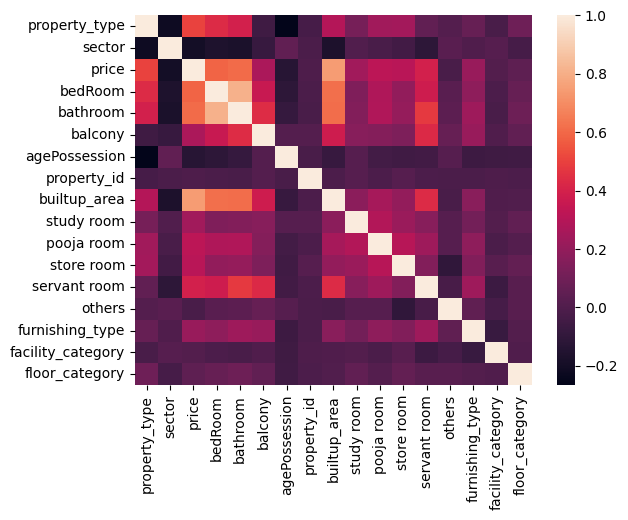

In [31]:
sns.heatmap(encoded_df.corr())

In [32]:
f1 = encoded_df.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index': 'feature', 'price': 'corr_coeff'})

In [33]:
f1

,feature,corr_coeff
0,sector,-0.197200
1,price,1.000000
2,bedRoom,0.589577
3,bathroom,0.606704
4,balcony,0.269175
5,agePossession,-0.136934
6,property_id,-0.005601
7,builtup_area,0.745015
8,study room,0.242112
9,pooja room,0.319299


### 2. Random Forest Feature Importance

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

RandomForestRegressor(random_state=42)

In [35]:
f2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf.feature_importances_ 
}).sort_values(by='rf_importance', ascending=False)

f2

,feature,rf_importance
7,builtup_area,0.633807
0,property_type,0.114235
1,sector,0.098657
6,property_id,0.037163
3,bathroom,0.021052
11,servant room,0.020803
2,bedRoom,0.019458
5,agePossession,0.012529
4,balcony,0.011003
10,store room,0.006243


### 3. Gradient Boosting Feature Importance

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_label, y_label)

GradientBoostingRegressor()

In [37]:
f3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb.feature_importances_ 
}).sort_values(by='gb_importance', ascending=False)

f3

,feature,gb_importance
7,builtup_area,0.663532
1,sector,0.106271
0,property_type,0.104680
2,bedRoom,0.033043
3,bathroom,0.031527
11,servant room,0.025167
6,property_id,0.016089
10,store room,0.010578
5,agePossession,0.002965
4,balcony,0.001896


### 4. Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_label, y_label, test_size=.2, random_state=42)

# base model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)

In [40]:
f4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

f4

,feature,permutation_importance
7,builtup_area,0.701097
0,property_type,0.256696
1,sector,0.134834
11,servant room,0.009640
3,bathroom,0.006940
5,agePossession,0.006666
6,property_id,0.003375
2,bedRoom,0.001924
15,floor_category,0.001226
14,facility_category,0.001197


### 5. LASSO

linear models are not much reliable here because data is ordinally encoded and linear models performs worst on ordinally encoded data.

*must use OHE when dealing with linear models*

In [41]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

lasso = Lasso(alpha=.01, random_state=42)
lasso.fit(X_scaled, y_label)

Lasso(alpha=0.01, random_state=42)

In [43]:
f5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

f5

,feature,lasso_coeff
7,builtup_area,1.464664
0,property_type,0.703225
3,bathroom,0.294254
10,store room,0.202258
8,study room,0.166716
11,servant room,0.160843
13,furnishing_type,0.133650
9,pooja room,0.069045
14,facility_category,0.051326
6,property_id,0.019566


### 6. Recursive Feature Elemination (RFE)

In [ ]:
from sklearn.feature_selection import RFE

# base model
estimator = RandomForestRegressor()

selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# get selected features
selected_features = X_label.columns[selector_label.support_]

selected_features_coeffs = selector_label.estimator_.feature_importances_

In [45]:
f6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_features_coeffs
}).sort_values(by='rfe_score', ascending=False)

f6

,feature,rfe_score
7,builtup_area,0.634339
0,property_type,0.106254
1,sector,0.098899
6,property_id,0.034889
3,bathroom,0.022544
2,bedRoom,0.022390
11,servant room,0.020127
5,agePossession,0.012767
4,balcony,0.010876
10,store room,0.007697


### 7. Linear Regression Weights

In [46]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_scaled, y_label)

LinearRegression()

In [47]:
f7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeff': reg.coef_
}).sort_values(by='reg_coeff', ascending=False)

f7

,feature,reg_coeff
7,builtup_area,1.468588
0,property_type,0.702962
3,bathroom,0.306624
10,store room,0.206358
8,study room,0.174923
11,servant room,0.169790
13,furnishing_type,0.143142
9,pooja room,0.072377
14,facility_category,0.062504
6,property_id,0.029759


### 8. SHAP

In [48]:
import shap

# base estimator
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_label)

shap_sum = np.abs(shap_vals).mean(axis=0)
shap_vals

d:\Projects\capstone-project\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([[ 1.69325806,  0.63642757,  0.07286035, ..., -0.01900874,
        -0.01450549, -0.00627869],
       [-0.50514562,  0.43516936, -0.02149647, ...,  0.01833429,
         0.02767968, -0.04918649],
       [-0.16481906,  0.57826164, -0.02926754, ..., -0.00305173,
        -0.0051866 , -0.01143909],
       ...,
       [-0.201282  , -0.19685719,  0.00984549, ..., -0.00362687,
         0.01617617,  0.04057044],
       [-0.4132276 , -0.08876706, -0.01811931, ..., -0.01532141,
        -0.00678534, -0.05375881],
       [-0.2075945 ,  0.60561158, -0.0020579 , ...,  0.0032912 ,
         0.00190007, -0.00846853]])

In [49]:
f8 = pd.DataFrame({
    'feature': X_label.columns,
    'shap_score': np.abs(shap_vals).mean(axis=0)
}).sort_values(by='shap_score', ascending=False)

f8

,feature,shap_score
7,builtup_area,1.231808
0,property_type,0.499031
1,sector,0.367652
3,bathroom,0.104593
11,servant room,0.104431
6,property_id,0.042747
2,bedRoom,0.042096
4,balcony,0.037253
5,agePossession,0.022026
15,floor_category,0.020396


In [50]:
final_fi_df = f1.merge(f2,on='feature').merge(f3,on='feature').merge(f4,on='feature').merge(f5,on='feature').merge(f6,on='feature').merge(f7,on='feature').merge(f8,on='feature').set_index('feature')
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeff,shap_score
feature,,,,,,,,
sector,-0.197200,0.098657,0.106271,0.134834,-0.051599,0.098899,-0.060268,0.367652
bedRoom,0.589577,0.019458,0.033043,0.001924,0.000000,0.022390,-0.005127,0.042096
bathroom,0.606704,0.021052,0.031527,0.006940,0.294254,0.022544,0.306624,0.104593
balcony,0.269175,0.011003,0.001896,-0.004303,-0.058246,0.010876,-0.081410,0.037253
agePossession,-0.136934,0.012529,0.002965,0.006666,-0.000000,0.012767,-0.003786,0.022026
property_id,-0.005601,0.037163,0.016089,0.003375,0.019566,0.034889,0.029759,0.042747
builtup_area,0.745015,0.633807,0.663532,0.701097,1.464664,0.634339,1.468588,1.231808
study room,0.242112,0.004800,0.001408,-0.003022,0.166716,0.005116,0.174923,0.014748
pooja room,0.319299,0.003214,0.000000,-0.001130,0.069045,0.003918,0.072377,0.006560


In [51]:
# taking average as final values

# normalizing to same scale
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [52]:
final_fi_df[['rf_importance', 'gb_importance', 'permutation_importance', 'rfe_score', 'shap_score']].sum(axis=1).sort_values(ascending=False)

feature
builtup_area         3.589916
sector               0.678345
bathroom             0.143414
servant room         0.136411
property_id          0.123793
bedRoom              0.106737
agePossession        0.050313
balcony              0.039854
store room           0.028370
floor_category       0.024318
facility_category    0.022578
furnishing_type      0.021596
study room           0.016374
pooja room           0.009891
others               0.008089
dtype: float64

thinking about removing the cols = study room, others

In [53]:
# first we'll train the random forest model with and w/0 this cols and compare the r2 score and then take the decision

# all features
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [54]:
scores.mean()

np.float64(0.8076287663450165)

In [55]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X_label.drop(columns=['study room', 'others']), y_label, cv=5, scoring='r2')

In [56]:
scores.mean()

np.float64(0.811706593885815)

In [57]:
export_df = X_label.drop(columns=['study room', 'others'])
export_df['price'] = y_label

In [58]:
export_df.to_csv('../datasets/final_dataset_feature_selection_v6.csv', index=False)